In [23]:
from scripts.AbstractExperiments import ExperimentRunner, GenerateConfigs
from EnvironmentBuilder.SearchRescue.Rescue import Rescue
import EnvironmentBuilder.SearchRescue.Drawing as SearchRescueDraw
from scripts.TexTables import SaveDataFrameToTexTemplate
from copy import deepcopy
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "Charter",
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})
def latex_config_name(name):
    return "$" + name.replace("^0", "^{0}") + "$"

In [24]:
def GenerateTeamConfigs(teams_:list, name_prefix=None):
    configs = {}
    if name_prefix is None:
        name_prefix = f"{len(teams_)}_"
    # Act-Utilitarianism
    con = {"Theories": [["Add_Util", "Utility", 0]], "Considerations": []}
    for t in teams_:
        con["Considerations"].append([f"{t}:wellbeing", "Add_Util"])
    configs[f"{name_prefix}add"] = con

    # Balance
    con = {"Theories": [], "Considerations": []}
    for t in teams_:
        con["Theories"].append([f"{t}", "Utility", 0])
        con["Considerations"].append([f"{t}:wellbeing", f"{t}"])
    configs[f"{name_prefix}bal"] = con

    # Fairness
    con = {"Theories": [["Fair", "Fairness", 0]], "Considerations": []}
    for t in teams_:
        con["Considerations"].append([f"{t}:wellbeing", ["Fair"]])
    configs[f"{name_prefix}fair"] = con

    # Fairness + Others
    con = {"Theories": [["Fair", "Fairness", 0]], "Considerations": []}
    for t in teams_:
        con["Theories"].append([f"{t}", "Utility", 0])
        con["Considerations"].append([f"{t}:wellbeing", [f"{t}", "Fair"]])
    configs[f"{name_prefix}fair_bal"] = con

    # Fairness + Act-Utilitarianism
    con = {"Theories": [["Fair", "Fairness", 0]], "Considerations": []}
    for t in teams_:
        con["Theories"].append([f"{t}", "Utility", 0])
        con["Considerations"].append([f"{t}:wellbeing", [f"{t}", "Fair"]])
    configs[f"{name_prefix}fair_AU"] = con

    # Rawls
    con = {"Theories":[["Rawls", "Maximin", 0]], "Considerations": []}
    for t in teams_:
        con["Considerations"].append([f"{t}:wellbeing", ["Rawls"]])
    configs[f"{name_prefix}rawl"] = con

    # Rawls + Others
    con = {"Theories": [["Rawls", "Maximin", 0]], "Considerations": []}
    for t in teams_:
        con["Theories"].append([f"{t}", "Utility", 0])
        con["Considerations"].append([f"{t}:wellbeing", [f"{t}", "Rawls"]])
    configs[f"{name_prefix}rawl_bal"] = con

    # Rawls + AU
    con = {"Theories": [["Rawls", "Maximin", 0], ["Add_Util", "Utility", 0]], "Considerations": []}
    for t in teams_:
        con["Theories"].append([f"{t}", "Utility", 0])
        con["Considerations"].append([f"{t}:wellbeing", ["Rawls", "Add_Util"]])
    configs[f"{name_prefix}rawl_AU"] = con

    return configs

def MakeTeamWeights(teams_):
    p = [2**i for i in range(0, len(teams_))]
    total = sum(p)
    w = [i / total for i in p]
    o = {}
    for t in teams_:
        for i, t in enumerate(teams_):
            o[f"{t}_hosp_success"] = w[i]
    return o

markers = {
    "Separate Theories": "o",
    "Act-Utilitarianism": "s",
    "Fairness": "^",
    "Rawls": "*",
    "Fair + balance": ".",
    "Rawls + balance": "x"
}
colours = {
    "Separate Theories": "blue",
    "Act-Utilitarianism": "black",
    "Fairness": "green",
    "Rawls": "red",
    "Fair + balance": "cyan",
    "Rawls + balance": "magenta",
}

## Generate environments, then run the planner

In [ ]:
env_reps = 1
config_list = []

for horizon_ in range(3, 7):
    for d in range(0, 4):
        teams = ["red", "blue", "green"]
        odds = MakeTeamWeights(teams)

        config_list += GenerateConfigs(
            inputConfigs=GenerateTeamConfigs(
                teams,
                name_prefix=f"{len(teams)}_h{horizon_}_d{d}"
            ),
            defaultConfig={
                "Horizon": horizon_,
                "Teams": teams,
                "unknown_depth": d,
                "Odds": odds
            }
        )
er = ExperimentRunner(
    "Rescue",
    config_list,
    MoralPlanner_Location="/../../",
    outFolder="Iterative_Search"
)
d = er.buildEnvironments()

In [ ]:
er.StartServer()
er.PlanWithLookahead("Rescue", er.rawOutFolder, look_ahead=3, config_index=0, act_ahead=1)


EXECUTE /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../MPlan/cmake-build-release/MPlan --debug 0 /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/Search/mdps/3_h3_d0add_con0.json /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/Search/raw/3_h3_d0add_con0_rep0.json
THE 2026 MACHINE ETHICS HYPOTHETICAL RETROSPECTION PLANNER (MEHR-PLAN)
JSON file '/home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/Search/raw/3_h3_d0add_con0_rep0.json' created successfully!
EXECUTE /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../MPlan/cmake-build-release/MPlan --debug 0 /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/Search/mdps/3_h3_d0bal_con0.json /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/Search/raw/3_h3_d0bal_con0_rep0.json
THE 2026 MACHINE ETHICS HYPOTHETICAL

In [36]:
er.extractData(1, env_reps)
df = pd.DataFrame(er.data)
df = df.drop(labels=['Conf_rep', 'Theories', 'Considerations', 'CQ1_time', 'CQ2_time', 'Out_time', 'Sol_reduce_time'],
             axis=1)
df = df.replace(["", "N/A", "NA", "nan", "None"], np.nan)

# ------------------------------------------------------------
# Extract environment parameters BEFORE changing Config_name
# ------------------------------------------------------------

df["communities"] = pd.to_numeric(
    df["Config_name"].str.extract(r"^(\d+)", expand=False),
    errors="coerce"
)

df["Horizon"] = pd.to_numeric(
    df["Config_name"].str.extract(r"_h(\d+)", expand=False),
    errors="coerce"
)

df["unknown_depth"] = pd.to_numeric(
    df["Config_name"].str.extract(r"_d(\d+)", expand=False),
    errors="coerce"
)

# ------------------------------------------------------------
# Convert configuration names to readable labels
# ------------------------------------------------------------

df["Config_name"] = np.select(
    [
        df["Config_name"].str.contains("fair_bal", case=False, na=False),
        df["Config_name"].str.contains("fair_AU", case=False, na=False),
        df["Config_name"].str.contains("rawl_bal", case=False, na=False),
        df["Config_name"].str.contains("rawl_AU", case=False, na=False),
        df["Config_name"].str.contains("add", case=False, na=False),
        df["Config_name"].str.contains("bal", case=False, na=False),
        df["Config_name"].str.contains("fair", case=False, na=False),
        df["Config_name"].str.contains("rawl", case=False, na=False),
    ],
    [
        "Fair + Separate",
        "Fair + AU",
        "Rawls + Separate",
        "Rawls + AU",
        "Act-Utilitarianism",
        "Separate Theories",
        "Fairness",
        "Rawls",
    ],
    default=df["Config_name"]
)

df.head(500)

,Config_name,Env_rep,Total_time,Heuristic_time,Plan_time,Sol_time,Mehr_time,Expanded_states,BSG_states,Average_histories,...,Min_non_accept,Num_of_min_non_accept,Num_of_sols,Total_Attacks,Total_reachable_policies,blue:wellbeing,green:wellbeing,red:wellbeing,communities,unknown_depth
0,Act-Utilitarianism,0,98,10,30,57,1,16,18,3,...,0.000000,1,3,4,21,0,1.1429,0,3,0
1,Separate Theories,0,106,9,40,55,2,16,18,3,...,2.000000,3,3,18,21,0,1.1429,0,3,0
2,Fairness,0,99,10,30,57,2,16,18,3,...,0.000000,1,3,4,21,0,0,0.2857,3,0
3,Fair + Separate,0,96,9,29,55,3,16,18,3,...,2.000000,1,3,22,21,0,0,0.2857,3,0
4,Fair + AU,0,106,9,29,65,3,16,18,3,...,2.000000,1,3,22,21,0,0,0.2857,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,Fair + Separate,0,111662,80,99992,4323,7267,138,178,13,...,2.814066,1,101,5283,8205220811478,1.4286,0,0,3,3
124,Fair + AU,0,108257,154,100734,3661,3708,138,178,13,...,2.814066,1,101,5283,8205220811478,1.4286,0,0,3,3
125,Rawls,0,112368,107,100170,3604,8487,138,178,13,...,0.000000,1,101,2336,8205220811478,1.1488,1.1726,1.1369,3,3
126,Rawls + Separate,0,113080,80,100167,3635,9198,138,178,13,...,2.777778,1,101,6331,8205220811478,1.125,1.125,1.1607,3,3


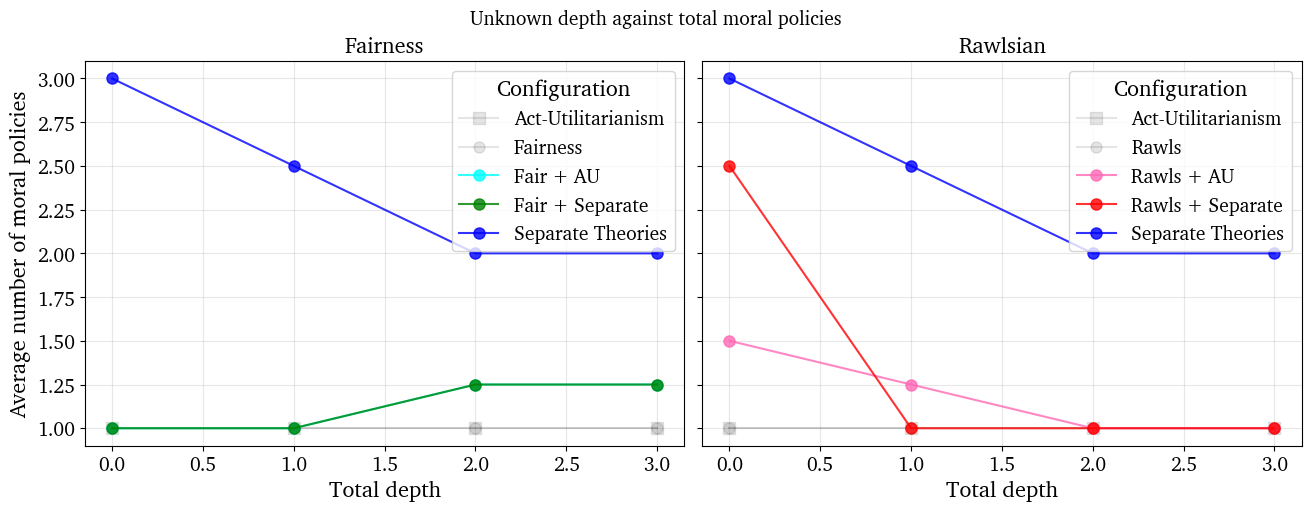

In [37]:
plot_df = df.reset_index().copy()

configurations = [
    "Rawls",
    "Fair + Separate",
    "Rawls + Separate",
    "Fair + AU",
    "Rawls + AU",
    "Act-Utilitarianism",
    "Separate Theories",
    "Fairness",
]

markers = {
    "Separate Theories": "o",
    "Act-Utilitarianism": "s",
    "Fairness": "o",
    "Rawls": "o",
    "Fair + balance": ".",
    "Rawls + balance": "x"
}
colours = {
    "Act-Utilitarianism": "black",
    "Rawls": "black",
    "Fairness": "black",

    "Separate Theories": "blue",
    "Fair + Separate": "green",
    "Fair + AU": "cyan",
    "Rawls + Separate": "red",
    "Rawls + AU": "hotpink",
}
opacity = {
    "Act-Utilitarianism": 0.1,
    "Rawls": 0.1,
    "Fairness": 0.1,

    "Separate Theories": 0.8,
    "Fair + Separate": 0.8,
    "Fair + AU": 0.8,
    "Rawls + Separate": 0.8,
    "Rawls + AU": 0.8,
}

plot_df = plot_df[
    plot_df["Config_name"].isin(configurations)
].copy()

# Average Num_of_min_non_accept for each configuration and community count
avg_df = (
    plot_df
    .groupby(["Config_name", "unknown_depth"], as_index=False)[
        "Num_of_min_non_accept"
    ]
    .mean()
    .sort_values(["Config_name", "unknown_depth"])
)

# Choose which configurations appear in each panel
configuration_groups = {
    "Fairness": [
        "Act-Utilitarianism",
        "Fairness",
        "Fair + AU",
        "Fair + Separate",
        "Separate Theories",
            
    ],
    "Rawlsian": [
        "Act-Utilitarianism",
        "Rawls",
        "Rawls + AU",
        "Rawls + Separate",
        "Separate Theories",
    ],
}

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(13, 5),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for ax, (panel_title, panel_configurations) in zip(
    axes,
    configuration_groups.items(),
):
    panel_df = avg_df[
        avg_df["Config_name"].isin(panel_configurations)
    ]

    # Iterating over this list explicitly controls the plotting
    # order and therefore the legend order.
    for config in panel_configurations:
        group = panel_df[
            panel_df["Config_name"] == config
        ].sort_values("unknown_depth")

        # Skip configurations that have no data in this panel.
        if group.empty:
            continue

        ax.plot(
            group["unknown_depth"],
            group["Num_of_min_non_accept"],
            marker=markers.get(config, "o"),
            markersize=8,
            alpha=opacity.get(config, 0.8),
            color=colours.get(config, "blue"),
            label=config,
        )

    ax.set_title(panel_title)
    ax.set_xlabel("Total depth")
    ax.grid(True, alpha=0.3)
    ax.legend(title="Configuration")

# The shared y-axis only needs a label on the left panel
axes[0].set_ylabel("Average number of moral policies")

fig.suptitle(
    "Unknown depth against total moral policies",
    fontsize=14,
)

plt.show()

## Get community wellbeing data for each individual policy

In [38]:
cols = [f"{t}:wellbeing" for t in teams]
worth_df = pd.DataFrame(er.GetWorthData(worth_tags=[f"{t}:wellbeing" for t in teams], envRepetitions=env_reps))
for t in cols:
    worth_df[t] = pd.to_numeric(worth_df[t])
worth_df = worth_df.drop(columns=["Conf_rep"])
worth_df = worth_df.replace(["", "N/A", "NA", "nan", "None"], np.nan)

worth_df["communities"] = pd.to_numeric(
    worth_df["Config_name"].str.extract(r"^(\d+)", expand=False),
    errors="coerce"
)

worth_df["Horizon"] = pd.to_numeric(
    worth_df["Config_name"].str.extract(r"_h(\d+)", expand=False),
    errors="coerce"
)

worth_df["unknown_depth"] = pd.to_numeric(
    worth_df["Config_name"].str.extract(r"_d(\d+)", expand=False),
    errors="coerce"
)

worth_df["Config_name"] = np.select(
    [
        worth_df["Config_name"].str.contains("fair_bal", case=False, na=False),
        worth_df["Config_name"].str.contains("fair_AU", case=False, na=False),
        worth_df["Config_name"].str.contains("rawl_bal", case=False, na=False),
        worth_df["Config_name"].str.contains("rawl_AU", case=False, na=False),
        worth_df["Config_name"].str.contains("add", case=False, na=False),
        worth_df["Config_name"].str.contains("bal", case=False, na=False),
        worth_df["Config_name"].str.contains("fair", case=False, na=False),
        worth_df["Config_name"].str.contains("rawl", case=False, na=False),
    ],
    [   
        "Fair + Separate",
        "Fair + AU",
        "Rawls + Separate",
        "Rawls + AU",
        "Act-Utilitarianism",
        "Separate Theories",
        "Fairness",
        "Rawls",
    ],
    default=worth_df["Config_name"]
)
worth_df

,Config_name,Env_rep,Horizon,Moral_policy_idx,Non-acceptability,red:wellbeing,blue:wellbeing,green:wellbeing,communities,unknown_depth
0,Act-Utilitarianism,0,3,0,0.000000,0.0000,0.0000,1.1429,3,0
1,Separate Theories,0,3,0,2.000000,0.0000,0.0000,1.1429,3,0
2,Separate Theories,0,3,1,2.000000,0.0000,0.5714,0.0000,3,0
3,Separate Theories,0,3,2,2.000000,0.2857,0.0000,0.0000,3,0
4,Fairness,0,3,0,0.000000,0.2857,0.0000,0.0000,3,0
...,...,...,...,...,...,...,...,...,...,...
158,Fair + Separate,0,6,0,2.814066,0.0000,1.4286,0.0000,3,3
159,Fair + AU,0,6,0,2.814066,0.0000,1.4286,0.0000,3,3
160,Rawls,0,6,0,0.000000,1.1369,1.1488,1.1726,3,3
161,Rawls + Separate,0,6,0,2.777778,1.1607,1.1250,1.1250,3,3


## Community wellbeing statistics by unknown depth

For every moral policy, calculate the minimum, maximum, mean, and population standard deviation across the three communities. The plots then average each policy-level statistic for every configuration and unknown-depth level (across horizons and environment repetitions).

In [39]:
policy_df = worth_df.copy()

wellbeing_cols = [
    column for column in policy_df.columns
    if column.endswith(":wellbeing")
]
if not wellbeing_cols:
    raise ValueError("No community wellbeing columns were found.")

policy_df[wellbeing_cols] = policy_df[wellbeing_cols].apply(
    pd.to_numeric, errors="coerce"
)

metric_columns = {
    "Minimum": "Policy wellbeing minimum",
    "Maximum": "Policy wellbeing maximum",
    "Mean": "Policy wellbeing mean",
    "Standard deviation": "Policy wellbeing standard deviation",
}

policy_df[metric_columns["Minimum"]] = policy_df[wellbeing_cols].min(axis=1, skipna=True)
policy_df[metric_columns["Maximum"]] = policy_df[wellbeing_cols].max(axis=1, skipna=True)
policy_df[metric_columns["Mean"]] = policy_df[wellbeing_cols].mean(axis=1, skipna=True)
policy_df[metric_columns["Standard deviation"]] = policy_df[wellbeing_cols].std(
    axis=1, skipna=True, ddof=0
)

depth_wellbeing_summary = (
    policy_df
    .dropna(subset=["unknown_depth"])
    .groupby(["Config_name", "unknown_depth"], observed=True)[
        list(metric_columns.values())
    ]
    .mean()
    .reset_index()
    .sort_values(["Config_name", "unknown_depth"])
)
depth_wellbeing_summary.round(4)

,Config_name,unknown_depth,Policy wellbeing minimum,Policy wellbeing maximum,Policy wellbeing mean,Policy wellbeing standard deviation
0,Act-Utilitarianism,0,0.0000,2.0000,0.6667,0.9428
1,Act-Utilitarianism,1,0.5000,1.3572,0.7857,0.4041
2,Act-Utilitarianism,2,0.6875,1.1875,0.8542,0.2357
3,Act-Utilitarianism,3,0.7188,1.1830,0.8735,0.2189
4,Fair + AU,0,0.0000,0.5000,0.1667,0.2357
5,Fair + AU,1,0.5000,0.7143,0.5714,0.1010
6,Fair + AU,2,0.6000,0.8857,0.6952,0.1347
7,Fair + AU,3,0.4000,0.9572,0.5857,0.2626
8,Fair + Separate,0,0.0000,0.5000,0.1667,0.2357
9,Fair + Separate,1,0.5000,0.7143,0.5714,0.1010


### Overview: compare depth levels within each wellbeing statistic

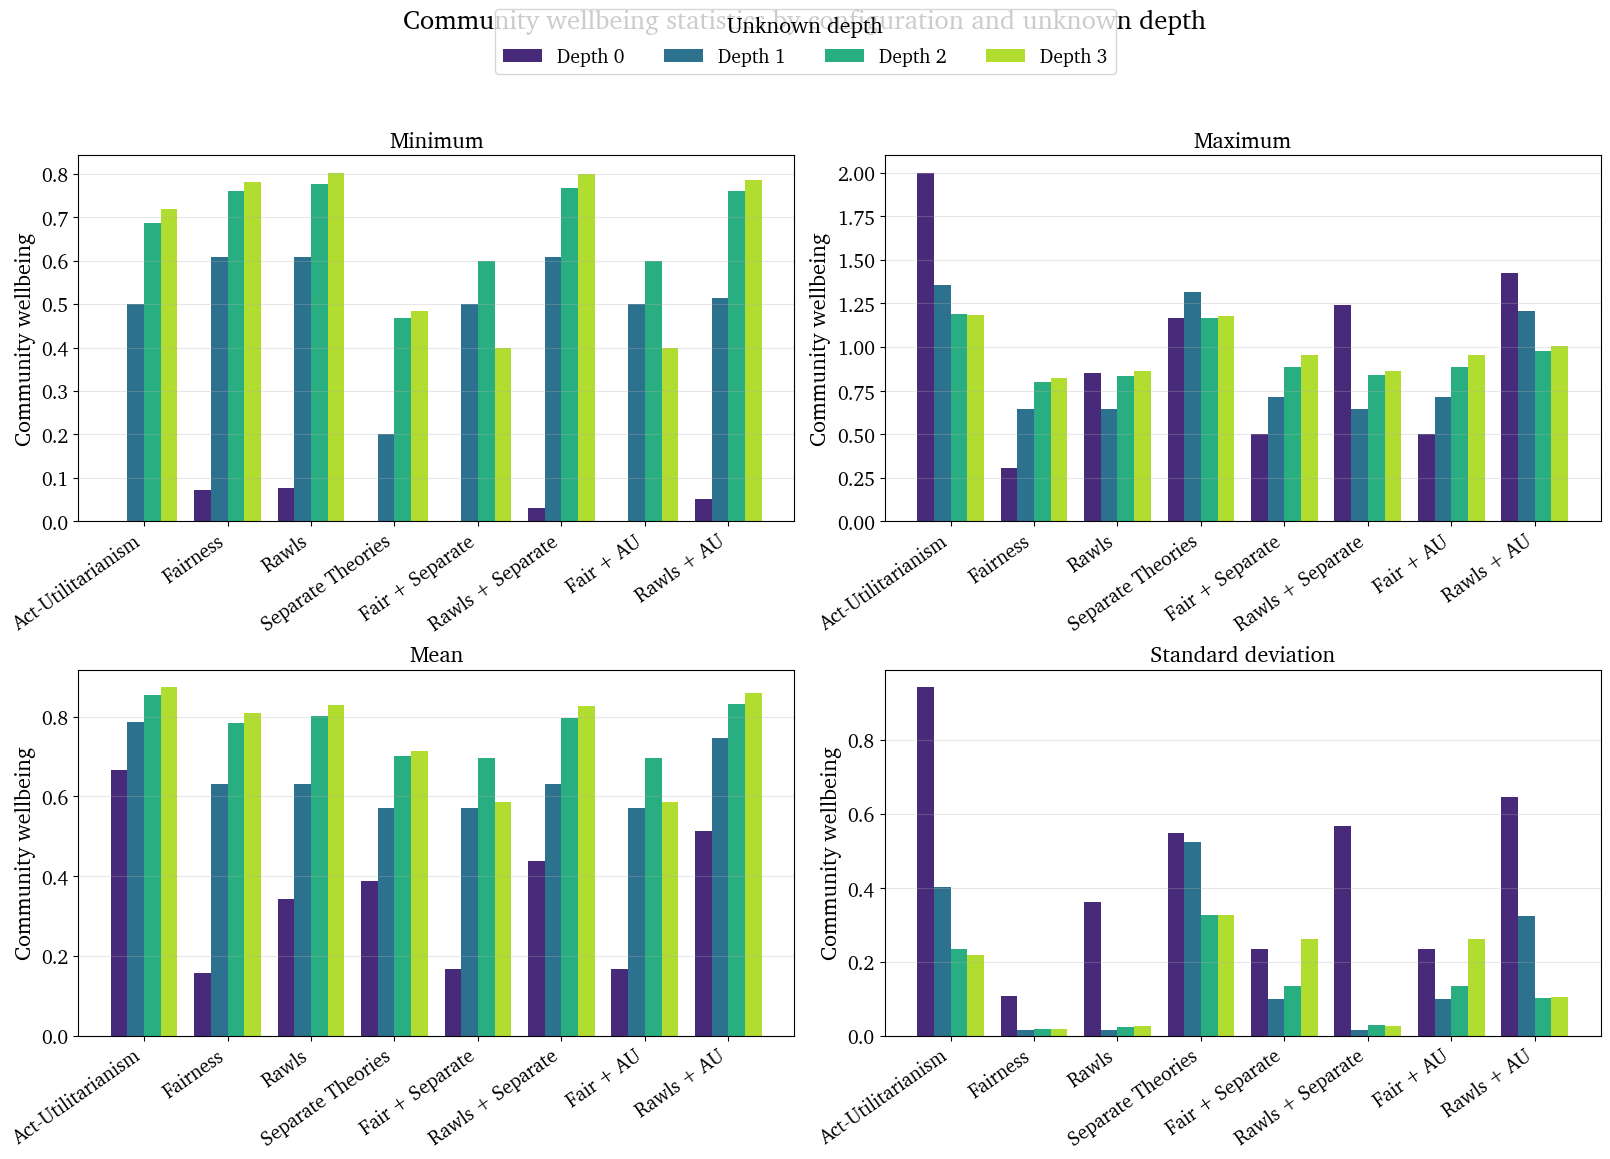

In [40]:
configuration_order = [
    "Act-Utilitarianism",
    "Fairness",
    "Rawls",
    "Separate Theories",
    "Fair + Separate",
    "Rawls + Separate",
    "Fair + AU",
    "Rawls + AU",
]
configuration_order = [
    config for config in configuration_order
    if config in depth_wellbeing_summary["Config_name"].unique()
]
depth_order = sorted(
    depth_wellbeing_summary["unknown_depth"].dropna().unique()
)
depth_colours = plt.cm.viridis(np.linspace(0.12, 0.88, len(depth_order)))

fig, axes = plt.subplots(2, 2, figsize=(16, 11), constrained_layout=True)
x = np.arange(len(configuration_order))
bar_width = 0.8 / max(len(depth_order), 1)

for ax, (metric_label, metric_column) in zip(axes.flat, metric_columns.items()):
    pivot = depth_wellbeing_summary.pivot(
        index="Config_name",
        columns="unknown_depth",
        values=metric_column,
    ).reindex(index=configuration_order, columns=depth_order)

    for depth_index, depth in enumerate(depth_order):
        positions = x + (depth_index - (len(depth_order) - 1) / 2) * bar_width
        ax.bar(
            positions,
            pivot[depth].to_numpy(),
            width=bar_width,
            color=depth_colours[depth_index],
            label=f"Depth {int(depth)}",
        )

    ax.set_title(metric_label)
    ax.set_xticks(x)
    ax.set_xticklabels(configuration_order, rotation=35, ha="right")
    ax.set_ylabel("Community wellbeing")
    ax.grid(axis="y", alpha=0.3)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Unknown depth", loc="outside upper center", ncols=len(depth_order))
fig.suptitle("Community wellbeing statistics by configuration and unknown depth", y=1.04)
plt.show()

### Detail: all four statistics for each configuration

Each panel isolates one configuration. Within each unknown-depth group, the four bars show how the distribution of wellbeing between communities changes.

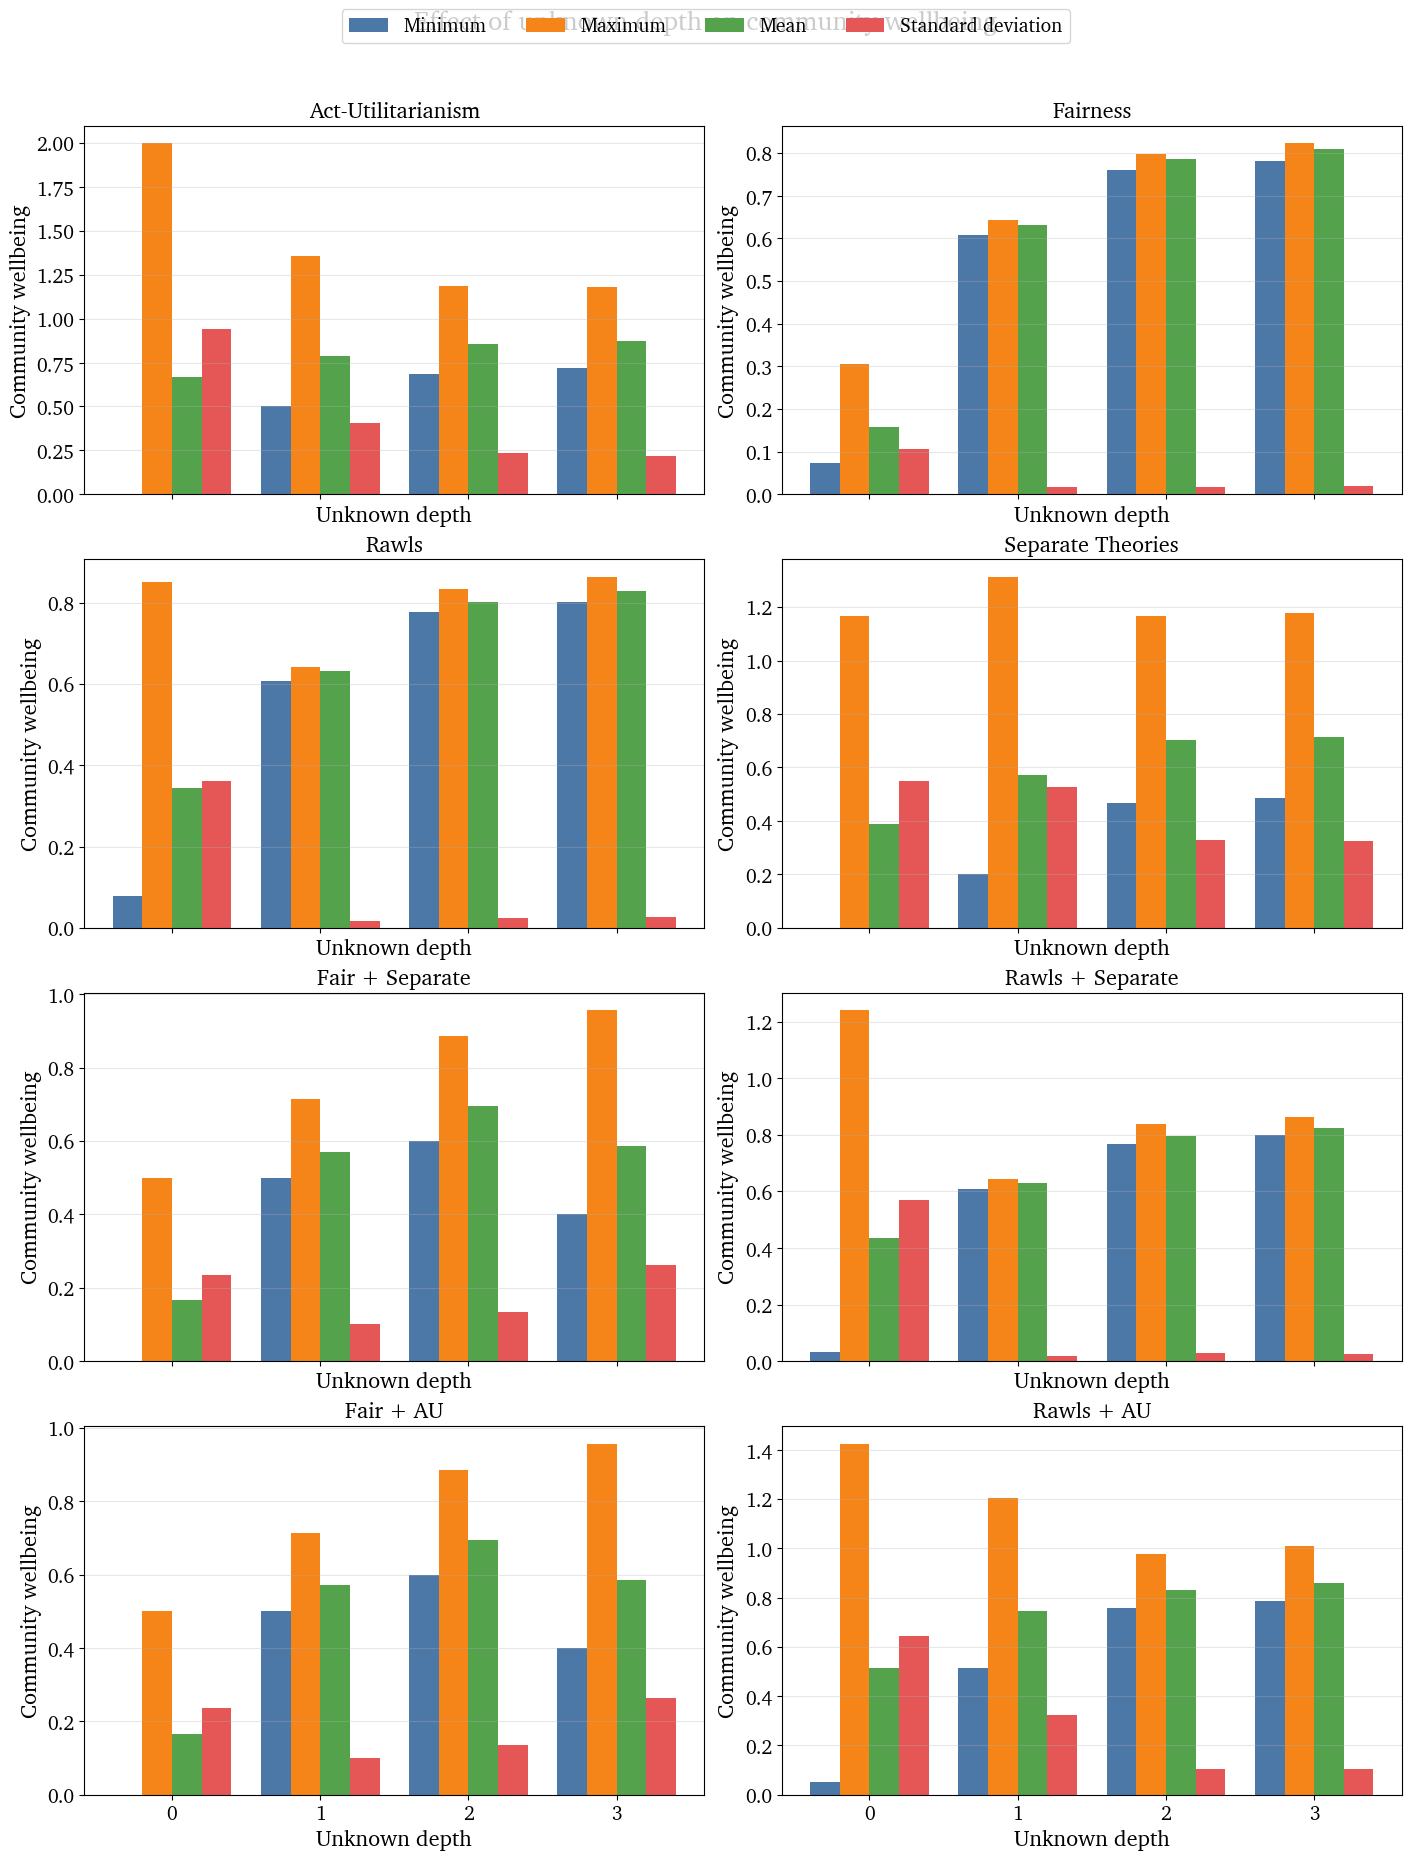

In [41]:
metric_colours = {
    "Minimum": "#4C78A8",
    "Maximum": "#F58518",
    "Mean": "#54A24B",
    "Standard deviation": "#E45756",
}

ncols = 2
nrows = int(np.ceil(len(configuration_order) / ncols))
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(14, 4.5 * nrows),
    sharex=True,
    constrained_layout=True,
)
axes = np.atleast_1d(axes).ravel()
x = np.arange(len(depth_order))
bar_width = 0.8 / len(metric_columns)

for ax, config in zip(axes, configuration_order):
    config_data = (
        depth_wellbeing_summary[depth_wellbeing_summary["Config_name"] == config]
        .set_index("unknown_depth")
        .reindex(depth_order)
    )

    for metric_index, (metric_label, metric_column) in enumerate(metric_columns.items()):
        positions = x + (metric_index - (len(metric_columns) - 1) / 2) * bar_width
        ax.bar(
            positions,
            config_data[metric_column].to_numpy(),
            width=bar_width,
            color=metric_colours[metric_label],
            label=metric_label,
        )

    ax.set_title(config)
    ax.set_xticks(x)
    ax.set_xticklabels([int(depth) for depth in depth_order])
    ax.set_xlabel("Unknown depth")
    ax.set_ylabel("Community wellbeing")
    ax.grid(axis="y", alpha=0.3)

for ax in axes[len(configuration_order):]:
    ax.remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside upper center", ncols=len(metric_columns))
fig.suptitle("Effect of unknown depth on community wellbeing", y=1.025)
plt.show()

## Reusable configuration and metric plotting function

Use `depth_wellbeing_summary` (or `policy_df`) for community wellbeing and `df` for planner-run metrics such as runtime, states, backups, or policy counts. The dependent variables are the metrics being plotted; the independent variable is the x-axis. Short aliases `min`, `max`, `mean`, and `std` refer to the four policy wellbeing columns.


In [42]:
WELLBEING_METRIC_ALIASES = {
    "min": "Policy wellbeing minimum",
    "minimum": "Policy wellbeing minimum",
    "max": "Policy wellbeing maximum",
    "maximum": "Policy wellbeing maximum",
    "mean": "Policy wellbeing mean",
    "average": "Policy wellbeing mean",
    "std": "Policy wellbeing standard deviation",
    "standard deviation": "Policy wellbeing standard deviation",
}


def plot_configuration_metrics(
    data,
    configurations,
    independent_variable,
    dependent_variables,
    *,
    aggregation="mean",
    chart_type="line",
    variability=None,
    filters=None,
    log_y=False,
    title=None,
    metric_labels=None,
    figsize=None,
):
    """Plot one or more dependent variables against an independent variable.

    Parameters
    ----------
    data : pandas.DataFrame
        For run-level metrics such as time, pass ``df``. For policy-level
        wellbeing, pass ``depth_wellbeing_summary`` or ``policy_df``.
    configurations : str or sequence of str
        Configuration names to compare.
    independent_variable : str
        Column to place on the x-axis, for example ``"unknown_depth"``.
    dependent_variables : str or sequence of str
        Columns to plot. The aliases min, max, mean, and std select the four
        policy wellbeing statistics created above.
    aggregation : str, default "mean"
        How repeated rows at each configuration/x value are combined.
    chart_type : {"line", "bar"}, default "line"
        Use lines for trends or grouped bars for discrete comparisons.
    variability : {None, "std", "sem"}, default None
        Optional error bars calculated over repeated rows in ``data``.
    filters : mapping, optional
        Values to hold fixed, for example ``{"Horizon": 6}``.
    log_y : bool, default False
        Use a logarithmic y-axis; useful for rapidly growing runtimes.

    Returns
    -------
    fig, axes, summary
        The Matplotlib objects and the aggregated data used in the graph.
    """
    configurations = (
        [configurations]
        if isinstance(configurations, str)
        else list(configurations)
    )
    dependent_variables = (
        [dependent_variables]
        if isinstance(dependent_variables, str)
        else list(dependent_variables)
    )
    if not configurations:
        raise ValueError("Pass at least one configuration.")
    if not dependent_variables:
        raise ValueError("Pass at least one dependent variable/metric.")
    if chart_type not in {"line", "bar"}:
        raise ValueError("chart_type must be either 'line' or 'bar'.")
    if variability not in {None, "std", "sem"}:
        raise ValueError("variability must be None, 'std', or 'sem'.")

    resolved_metrics = []
    for metric in dependent_variables:
        alias = WELLBEING_METRIC_ALIASES.get(str(metric).lower(), metric)
        resolved_metrics.append(alias if alias in data.columns else metric)

    required_columns = {
        "Config_name",
        independent_variable,
        *resolved_metrics,
        *(filters or {}).keys(),
    }
    missing_columns = sorted(required_columns.difference(data.columns))
    if missing_columns:
        raise KeyError(f"Columns not found: {missing_columns}")

    plot_data = data[data["Config_name"].isin(configurations)].copy()
    for column, allowed_values in (filters or {}).items():
        if isinstance(allowed_values, (str, bytes)) or not hasattr(allowed_values, "__iter__"):
            allowed_values = [allowed_values]
        plot_data = plot_data[plot_data[column].isin(allowed_values)]

    numeric_independent = pd.to_numeric(
        plot_data[independent_variable], errors="coerce"
    )
    if numeric_independent.notna().equals(
        plot_data[independent_variable].notna()
    ):
        plot_data[independent_variable] = numeric_independent
    for metric in resolved_metrics:
        plot_data[metric] = pd.to_numeric(plot_data[metric], errors="coerce")

    plot_data = plot_data.dropna(
        subset=["Config_name", independent_variable, *resolved_metrics]
    )
    if plot_data.empty:
        raise ValueError("No rows remain after applying configurations and filters.")

    group_columns = ["Config_name", independent_variable]
    summary = (
        plot_data.groupby(group_columns, observed=True)[resolved_metrics]
        .agg(aggregation)
        .reset_index()
        .sort_values(group_columns)
    )
    error_summary = None
    if variability is not None:
        error_summary = (
            plot_data.groupby(group_columns, observed=True)[resolved_metrics]
            .agg(variability)
            .reset_index()
        )

    metric_count = len(resolved_metrics)
    ncols = min(2, metric_count)
    nrows = int(np.ceil(metric_count / ncols))
    if figsize is None:
        figsize = (7 * ncols, 4.8 * nrows)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        squeeze=False,
        constrained_layout=True,
    )
    axes = axes.ravel()
    x_order = sorted(summary[independent_variable].unique())
    x_positions = np.arange(len(x_order))
    config_colours = plt.cm.tab10(np.linspace(0, 1, len(configurations)))

    for ax, metric in zip(axes, resolved_metrics):
        for config_index, (config, colour) in enumerate(zip(configurations, config_colours)):
            config_data = (
                summary[summary["Config_name"] == config]
                .set_index(independent_variable)
                .reindex(x_order)
            )
            y_values = config_data[metric].to_numpy(dtype=float)
            y_error = None
            if error_summary is not None:
                y_error = (
                    error_summary[error_summary["Config_name"] == config]
                    .set_index(independent_variable)
                    .reindex(x_order)[metric]
                    .to_numpy(dtype=float)
                )

            if chart_type == "bar":
                bar_width = 0.8 / len(configurations)
                positions = (
                    x_positions
                    + (config_index - (len(configurations) - 1) / 2) * bar_width
                )
                ax.bar(
                    positions,
                    y_values,
                    width=bar_width,
                    yerr=y_error,
                    capsize=3 if y_error is not None else 0,
                    color=colour,
                    label=config,
                )
            else:
                ax.errorbar(
                    x_order,
                    y_values,
                    yerr=y_error,
                    marker="o",
                    capsize=3 if y_error is not None else 0,
                    color=colour,
                    label=config,
                )

        if chart_type == "bar":
            ax.set_xticks(x_positions)
            ax.set_xticklabels(x_order)
        ax.set_xlabel(independent_variable.replace("_", " ").title())
        ax.set_ylabel((metric_labels or {}).get(metric, metric.replace("_", " ")))
        ax.set_title((metric_labels or {}).get(metric, metric.replace("_", " ").title()))
        if log_y:
            ax.set_yscale("log")
        ax.grid(axis="y", alpha=0.3)
        ax.legend(title="Configuration")

    for ax in axes[metric_count:]:
        ax.remove()
    if title:
        fig.suptitle(title)
    return fig, axes[:metric_count], summary


### Example: compare minimum and maximum wellbeing

Change `wellbeing_configurations`, the metric aliases, or `chart_type` to generate a different comparison.


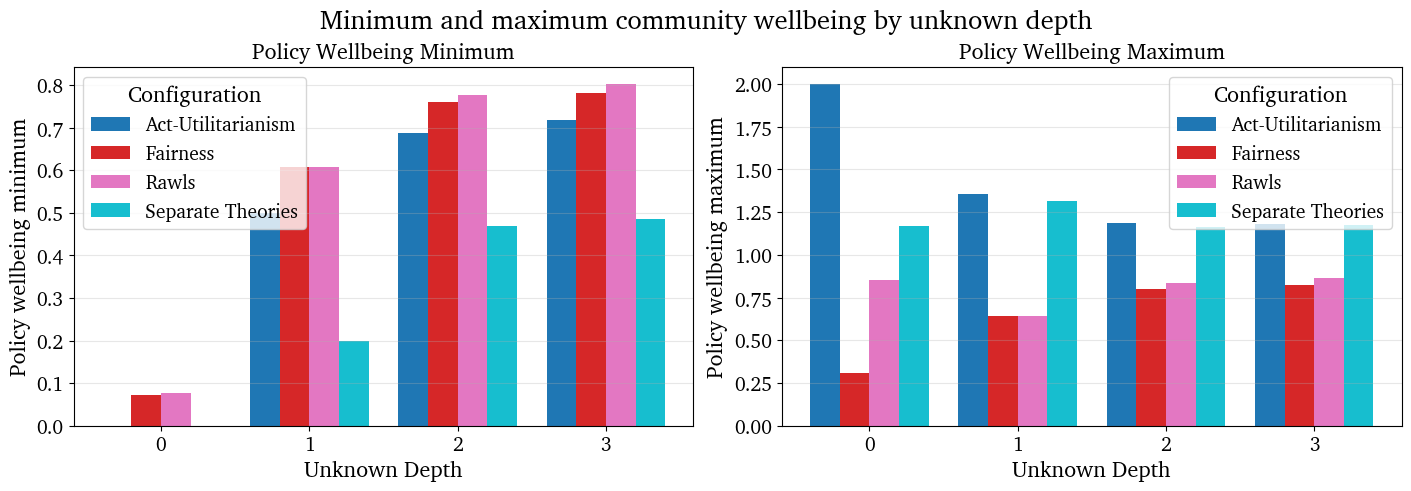

,Config_name,unknown_depth,Policy wellbeing minimum,Policy wellbeing maximum
0,Act-Utilitarianism,0,0.0000,2.0000
1,Act-Utilitarianism,1,0.5000,1.3572
2,Act-Utilitarianism,2,0.6875,1.1875
3,Act-Utilitarianism,3,0.7188,1.1830
4,Fairness,0,0.0729,0.3061
5,Fairness,1,0.6072,0.6428
6,Fairness,2,0.7589,0.7976
7,Fairness,3,0.7812,0.8229
8,Rawls,0,0.0780,0.8520
9,Rawls,1,0.6072,0.6428


In [34]:
wellbeing_configurations = [
    "Act-Utilitarianism",
    "Fairness",
    "Rawls",
    "Separate Theories",
]

wellbeing_figure, wellbeing_axes, wellbeing_graph_data = plot_configuration_metrics(
    depth_wellbeing_summary,
    configurations=wellbeing_configurations,
    independent_variable="unknown_depth",
    dependent_variables=["min", "max"],
    chart_type="bar",
    title="Minimum and maximum community wellbeing by unknown depth",
)
plt.show()
wellbeing_graph_data.round(4)


## Runtime complexity by unknown depth

Runtime uses `df`, where each row is one planner execution. The example holds horizon fixed at its largest tested value so that the effect of unknown depth is not mixed with the effect of horizon. The logarithmic y-axis makes large growth rates and differences between configurations easier to compare.

Change `runtime_configurations`, `runtime_horizon`, or `dependent_variables`. Other useful timing metrics are `Heuristic_time`, `Plan_time`, `Sol_time`, and `Mehr_time`. Remove `log_y=True` for a linear scale.


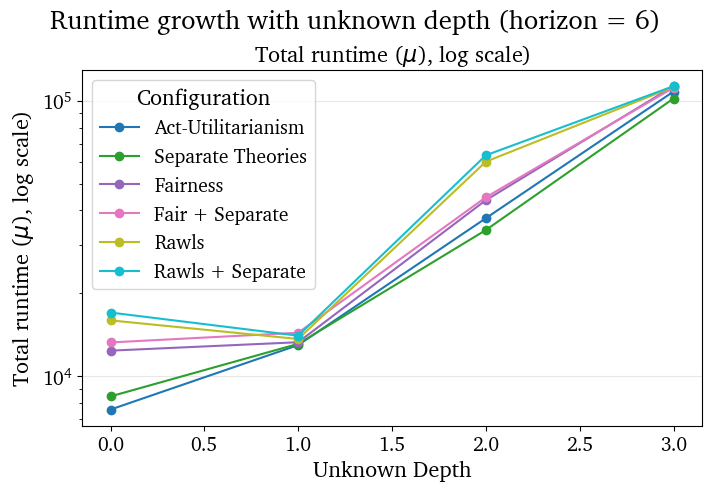

,Config_name,unknown_depth,Total_time
0,Act-Utilitarianism,0,7571.0
1,Act-Utilitarianism,1,12979.0
2,Act-Utilitarianism,2,37489.0
3,Act-Utilitarianism,3,108104.0
4,Fair + Separate,0,13269.0
5,Fair + Separate,1,14392.0
6,Fair + Separate,2,44671.0
7,Fair + Separate,3,111662.0
8,Fairness,0,12389.0
9,Fairness,1,13293.0


In [47]:
runtime_configurations = [
    "Act-Utilitarianism",
    "Separate Theories",
    "Fairness",
    "Fair + Separate",
    "Rawls",
    "Rawls + Separate",
]
runtime_horizon = int(pd.to_numeric(df["Horizon"], errors="coerce").max())

runtime_figure, runtime_axes, runtime_graph_data = plot_configuration_metrics(
    df,
    configurations=runtime_configurations,
    independent_variable="unknown_depth",
    dependent_variables="Total_time",
    filters={"Horizon": runtime_horizon},
    chart_type="line",
    log_y=True,
    metric_labels={f"Total_time": f"Total runtime ({latex_config_name("\\mu")}), log scale)"},
    title=f"Runtime growth with unknown depth (horizon = {runtime_horizon})",
)
plt.show()
runtime_graph_data.round(2)
